# Plausible Is Not Correct — hands-on demos

**Herbstseminar 2026 · Himanshu Beniwal (ScaDS.AI / TU Dresden)**

The pattern for every demo: **the LLM proposes, a curated database decides.**

| # | Demo | Ground truth used |
|---|------|-------------------|
| 1 | Are these references real? | Crossref, PubMed |
| 2 | Gene & protein facts | NCBI Gene, UniProtKB |
| 3 | Molecules & SMILES | PubChem (+ RDKit if installed) |
| 4 | "Quote or it didn't happen" (extraction from an abstract) | the abstract itself |
| 5 | Knowledge graphs: supported / not in KG / wrong in KG | Wikidata (SPARQL) |
| 6 | Self-consistency & multilingual consistency | UniProt / NCBI Gene |

**LLM backend.** `anthropic` if `ANTHROPIC_API_KEY` is set; otherwise `manual`: the notebook prints a prompt, you paste it
into *any* chatbot and paste the answer back (end with a line `END`). Set `PLAUSIBLE_LLM=off` to skip LLM calls.

**Offline.** All database answers are cached in `data/cache/`. Set `PLAUSIBLE_OFFLINE=1` to use only the cache.

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))      # make the `plausible` package importable
# os.environ["PLAUSIBLE_OFFLINE"] = "1"        # uncomment if the Wi-Fi is down
# os.environ["PLAUSIBLE_LLM"] = "manual"       # or "anthropic" / "off"

import pandas as pd
pd.set_option("display.max_colwidth", 120)
from plausible import literature, bio, chem, grounding, kg, llm

print("LLM backend:", llm.backend(), "| model:", llm.MODEL if llm.backend() == "anthropic" else "-")
print("RDKit available:", chem.HAVE_RDKIT)

LLM backend: off | model: -
RDKit available: False


---
## Demo 1 — Are these references real?

Fabricated references are among the best-documented LLM failures. Walters & Wilder (2023, *Sci Rep*) found
**55 %** of GPT-3.5 and **18 %** of GPT-4 citations to be fabricated. A 2026 study of ChatGPT-5 (Bernstein et al., *Cureus*)
still found **7.13 %** fabricated references, and only **49.34 %** fully accurate.

A reference can fail in three ways: the **ID does not exist**, the ID exists but **points to another paper**,
or the **metadata (year, authors) is wrong**. The list below was *constructed for teaching* and contains one example of each.

In [2]:
refs = [
    {"title": "Highly accurate protein structure prediction with AlphaFold",
     "doi": "10.1038/s41586-021-03819-2", "year": 2021, "first_author": "Jumper"},           # correct
    {"title": "Basic local alignment search tool", "pmid": "2231712",
     "year": 1990, "first_author": "Altschul"},                                               # correct
    {"title": "Gapped BLAST and PSI-BLAST: a new generation of protein database search programs",
     "doi": "10.1016/S0022-2836(05)80360-2", "year": 1997},                                   # real title, DOI of a different paper
    {"title": "Highly accurate protein structure prediction with AlphaFold",
     "doi": "10.1038/s41586-021-03819-2", "year": 2020, "first_author": "Jumper"},           # wrong year
    {"title": "Deep learning reveals universal CRISPR off-target rules",
     "doi": "10.1038/s41586-023-99999-9", "year": 2023},                                      # invented DOI
    {"title": "Fast, scalable generation of high-quality protein multiple sequence alignments using Clustal Omega"},  # no ID
    {"title": "A universal transformer for single-cell multi-omics integration across fifty species"},              # invented, no ID
]
results = [literature.check_reference(r) for r in refs]
pd.DataFrame(results)[["title", "doi", "pmid", "year", "verdict", "notes"]]

,title,doi,pmid,year,verdict,notes
0,Highly accurate protein structure prediction with AlphaFold,10.1038/s41586-021-03819-2,NaN,2021.0,VERIFIED,matches Crossref record
1,Basic local alignment search tool,NaN,2231712,1990.0,VERIFIED,matches PubMed record
2,Gapped BLAST and PSI-BLAST: a new generation of protein database search programs,10.1016/S0022-2836(05)80360-2,NaN,1997.0,MISMATCH,title similarity 0.23 — identifier belongs to: 'Basic local alignment search tool'; year claimed 1997 vs record 1990
3,Highly accurate protein structure prediction with AlphaFold,10.1038/s41586-021-03819-2,NaN,2020.0,MISMATCH,year claimed 2020 vs record 2021
4,Deep learning reveals universal CRISPR off-target rules,10.1038/s41586-023-99999-9,NaN,2023.0,NOT_FOUND,identifier does not resolve in Crossref
5,"Fast, scalable generation of high-quality protein multiple sequence alignments using Clustal Omega",NaN,NaN,NaN,FOUND_BY_TITLE,PMID 21988835
6,A universal transformer for single-cell multi-omics integration across fifty species,NaN,NaN,NaN,UNVERIFIABLE,no identifier; no title match in PubMed (check Google Scholar / bioRxiv)


**Read the verdicts carefully.** `UNVERIFIABLE` does **not** mean fake. PubMed does not index every venue
(conference papers, arXiv, bioRxiv). It means *you* now have to check by hand.

### Your turn (live LLM)
Ask the model for references with identifiers, then check them automatically.

In [3]:
prompt = '''List 5 peer-reviewed papers on using protein language models for predicting the effects of missense variants.
Return ONLY a JSON list of objects with keys: title, first_author, year, doi.
If you are not sure a paper exists, do not include it.'''
answer = llm.ask(prompt)
if answer:
    llm_refs = grounding.parse_json_block(answer)
    checked = [literature.check_reference(r) for r in llm_refs]
    display(pd.DataFrame(checked)[["title", "first_author", "year", "doi", "verdict", "notes"]])

[LLM backend is 'off' — skipping this call]


> **Discussion.** Did "if you are not sure, do not include it" help? Even when every DOI resolves, does each paper actually
> **support the claim you want to cite it for**? No database answers that. You have to read the paper.

---
## Demo 2 — Gene & protein facts against NCBI Gene and UniProt

Below are *constructed* claims of the kind an assistant might produce. One contains the classic BRCA1/BRCA2 mix-up,
and one has the wrong sex chromosome.

In [4]:
claims = [
    ("TP53",  "protein length (aa)", 393),
    ("CFTR",  "protein length (aa)", 1480),
    ("EGFR",  "protein length (aa)", 1210),
    ("BRCA1", "chromosome", "13"),     # BRCA2 is on 13; BRCA1 is on 17
    ("HBB",   "chromosome", "11"),
    ("DMD",   "chromosome", "Y"),      # DMD is X-linked
]
rows = []
for gene, attr, claimed in claims:
    if attr == "chromosome":
        rec = bio.ncbi_gene(gene); actual, src = rec["chromosome"], f"NCBI Gene {rec['gene_id']} ({rec['map_location']})"
        verdict = bio.compare(claimed, actual)
    else:
        rec = bio.uniprot_protein(gene); actual, src = rec["length_aa"], f"UniProt {rec['accession']}"
        verdict = bio.compare(claimed, actual, kind="number")
    rows.append({"gene": gene, "attribute": attr, "claimed": claimed, "database": actual, "source": src, "verdict": verdict})
pd.DataFrame(rows)

,gene,attribute,claimed,database,source,verdict
0,TP53,protein length (aa),393,393,UniProt P04637,SUPPORTED
1,CFTR,protein length (aa),1480,1480,UniProt P13569,SUPPORTED
2,EGFR,protein length (aa),1210,1210,UniProt P00533,SUPPORTED
3,BRCA1,chromosome,13,17,NCBI Gene 672 (17q21.31),CONTRADICTED
4,HBB,chromosome,11,11,NCBI Gene 3043 (11p15.4),SUPPORTED
5,DMD,chromosome,Y,X,NCBI Gene 1756 (Xp21.2-p21.1),CONTRADICTED


### Your turn (live LLM): structured output → automatic verification
Asking for **JSON** instead of prose turns "read and doubt" into "parse and check".

In [5]:
genes = ["TP53", "BRCA1", "BRCA2", "CFTR", "HTT", "DMD", "INS", "EGFR"]
prompt = f'''For each human gene in {genes}, give the chromosome it is located on and the length in amino acids
of its canonical protein isoform. Return ONLY a JSON list of objects with keys: gene, chromosome, length_aa.
Use null for anything you do not know.'''
answer = llm.ask(prompt)
if answer:
    rows = []
    for item in grounding.parse_json_block(answer):
        g = item["gene"]; ncbi = bio.ncbi_gene(g); uni = bio.uniprot_protein(g)
        rows.append({
            "gene": g,
            "chrom (LLM)": item.get("chromosome"), "chrom (NCBI)": ncbi["chromosome"],
            "chrom ok": bio.compare(item.get("chromosome"), ncbi["chromosome"]) if item.get("chromosome") else "ABSTAINED",
            "length (LLM)": item.get("length_aa"), "length (UniProt)": uni["length_aa"],
            "length ok": bio.compare(item["length_aa"], uni["length_aa"], kind="number") if item.get("length_aa") else "ABSTAINED",
        })
    display(pd.DataFrame(rows))

[LLM backend is 'off' — skipping this call]


> **Note.** "Canonical isoform" is a UniProt convention. If the model answers for a different isoform, it is not
> *hallucinating*: the question was under-specified. Good verification also checks whether **the question** was precise.

---
## Demo 3 — Molecules: names, formulas, SMILES

We compare structures by **InChIKey**, not by SMILES string: the same molecule can be written as many different SMILES.
The first block of an InChIKey encodes the skeleton. The second block encodes stereochemistry and other layers.

In [6]:
mol_claims = [
    dict(name="caffeine",    smiles="CN1C=NC2=C1C(=O)N(C(=O)N2C)C", formula="C8H10N4O2", mol_weight=194.19),
    dict(name="paracetamol", smiles="CC(=O)NC1=CC=C(C=C1)O",        formula="C8H9NO2",   mol_weight=151.16),
    dict(name="aspirin",     smiles="CC(=O)OC1=CC=CC=C1C(=O)OC",    mol_weight=180.16),   # methyl ester: a different molecule
    dict(name="levodopa",    smiles="C1=CC(=C(C=C1C[C@H](C(=O)O)N)O)O"),                   # wrong enantiomer (D-DOPA)
    dict(name="ibuprofen",   smiles="CC(C)CC1=CC=C(C=C1)C(C)C(=O)O", formula="C13H18O2", mol_weight=206.28),
    dict(name="aspirin",     smiles="C1=CC=CC=C1C(=O"),                                    # not a valid SMILES
]
pd.DataFrame([chem.check_molecule_claim(**c) for c in mol_claims]).fillna("")

,name,pubchem_cid,formula,mol_weight,smiles,verdict
0,caffeine,2519,OK,OK,OK (same InChIKey),ALL OK
1,paracetamol,1983,OK,OK,OK (same InChIKey),ALL OK
2,aspirin,2244,,OK,DIFFERENT MOLECULE,PROBLEM
3,levodopa,6047,,,"SAME SKELETON, different stereo/charge (InChIKey block 1 matches)",PROBLEM
4,ibuprofen,3672,OK,OK,OK (same InChIKey),ALL OK
5,aspirin,2244,,,INVALID or unparsable SMILES,PROBLEM


**Why levodopa matters.** L-DOPA is the Parkinson's drug. The D-enantiomer is a different compound. A string-level
"looks right" check would miss this. The InChIKey's stereo block catches it.

### Your turn (live LLM)

In [7]:
drugs = ["imatinib", "metformin", "sildenafil", "oseltamivir", "atorvastatin"]
prompt = f'''Give the SMILES and molecular formula for each of these drugs: {drugs}.
Return ONLY a JSON list of objects with keys: name, smiles, formula.'''
answer = llm.ask(prompt)
if answer:
    out = [chem.check_molecule_claim(d["name"], smiles=d.get("smiles"), formula=d.get("formula"))
           for d in grounding.parse_json_block(answer)]
    display(pd.DataFrame(out).fillna(""))

[LLM backend is 'off' — skipping this call]


> Better than asking the LLM for a SMILES string: ask it for the **name or identifier**, then **look the structure up**
> (PubChem/ChEMBL). That is the core idea behind tool-augmented systems such as ChemCrow (M. Bran et al., 2024) and GeneGPT (Jin et al., 2024).

---
## Demo 4 — "Quote or it didn't happen": grounded extraction

Task: extract results from an abstract. We demand an **exact supporting quote** for every item, then check the quotes
mechanically. The abstract is GeneGPT (Jin et al., 2024, *Bioinformatics*, PMID 38341654), fetched live from PubMed.

In [8]:
paper = literature.pubmed_abstract("38341654")
source = paper["title"] + "\n" + paper["abstract"]
print(source)

GeneGPT: augmenting large language models with domain tools for improved access to biomedical information.
MOTIVATION: While large language models (LLMs) have been successfully applied to various tasks, they still face challenges with hallucinations. Augmenting LLMs with domain-specific tools such as database utilities can facilitate easier and more precise access to specialized knowledge. In this article, we present GeneGPT, a novel method for teaching LLMs to use the Web APIs of the National Center for Biotechnology Information (NCBI) for answering genomics questions. Specifically, we prompt Codex to solve the GeneTuring tests with NCBI Web APIs by in-context learning and an augmented decoding algorithm that can detect and execute API calls.
RESULTS: Experimental results show that GeneGPT achieves state-of-the-art performance on eight tasks in the GeneTuring benchmark with an average score of 0.83, largely surpassing retrieval-augmented LLMs such as the new Bing (0.44), biomedical LL

Below is a **constructed** extraction (not real model output). Two items are faithful. One item has a **wrong number**
whose "quote" was altered to match. One item is **invented**, with a fabricated quote.

In [9]:
extracted = [
    {"system": "GeneGPT",  "score": 0.83, "quote": "achieves state-of-the-art performance on eight tasks in the GeneTuring benchmark with an average score of 0.83"},
    {"system": "new Bing", "score": 0.44, "quote": "retrieval-augmented LLMs such as the new Bing (0.44)"},
    {"system": "ChatGPT",  "score": 0.21, "quote": "GPT-3 (0.16) and ChatGPT (0.21)"},           # wrong: abstract says 0.12
    {"system": "GPT-4",    "score": 0.71, "quote": "GPT-4 reached an average score of 0.71"},    # invented
]
pd.DataFrame(grounding.check_extractions(extracted, source))

,system,score,quote,grounding,match_score
0,GeneGPT,0.83,achieves state-of-the-art performance on eight tasks in the GeneTuring benchmark with an average score of 0.83,EXACT,1.00
1,new Bing,0.44,retrieval-augmented LLMs such as the new Bing (0.44),EXACT,1.00
2,ChatGPT,0.21,GPT-3 (0.16) and ChatGPT (0.21),FUZZY,0.94
3,GPT-4,0.71,GPT-4 reached an average score of 0.71,ABSENT,0.68


`FUZZY` with a high score means *almost* the same text. That is exactly where a number may have been changed. Always
read FUZZY items by eye. Quote checking proves that the text exists. It does **not** prove that the text supports the claim.

### Your turn (live LLM)

In [10]:
prompt = f'''From the abstract below, extract every system that has a reported score.
Return ONLY a JSON list of objects with keys: system, score, quote.
"quote" must be copied EXACTLY, character for character, from the abstract.

ABSTRACT:
{source}'''
answer = llm.ask(prompt)
if answer:
    display(pd.DataFrame(grounding.check_extractions(grounding.parse_json_block(answer), source)))

[LLM backend is 'off' — skipping this call]


---
## Demo 5 — Knowledge graphs: supported, not in the KG, or *wrong in the KG*

Knowledge graphs store facts as `(subject, relation, object)` triples, which makes claims checkable. We query
**Wikidata** live: targets (`P129` *physically interacts with*) and indications (`P2175` *medical condition treated*) of imatinib.

In [11]:
triples = kg.drug_facts("imatinib")
G = kg.build_graph(triples)
pd.DataFrame(triples)

,subject,relation,object,qid
0,imatinib,interacts_with,"ABL proto-oncogene 1, non-receptor tyrosine kinase",Q587961
1,imatinib,interacts_with,"KIT proto-oncogene, receptor tyrosine kinase",Q909409
2,imatinib,interacts_with,Platelet derived growth factor receptor beta,Q21108624
3,imatinib,treats,leukemia,Q29496
4,imatinib,treats,acute myeloid leukemia,Q264118
5,imatinib,treats,graft-versus-host disease,Q1194520
6,imatinib,treats,dermatofibrosarcoma protuberans,Q1200239
7,imatinib,treats,gastrointestinal stromal tumor,Q1495661
8,imatinib,treats,gastrointestinal carcinoma,Q18553565
9,imatinib,treats,connective tissue benign neoplasm,Q18553680


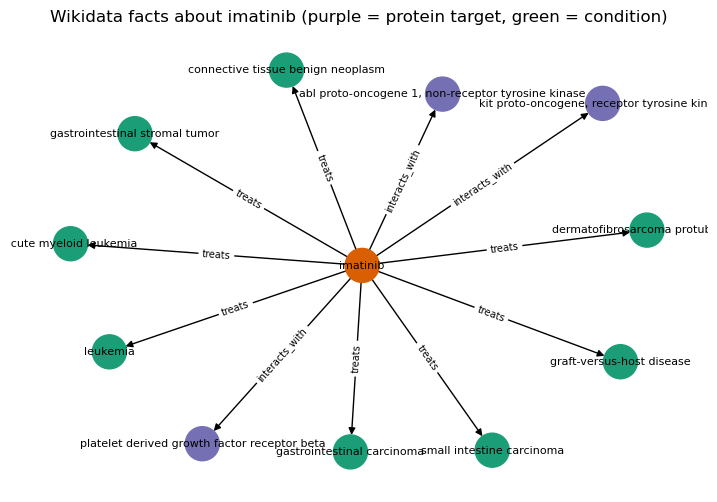

In [12]:
import matplotlib.pyplot as plt, networkx as nx
plt.figure(figsize=(9, 6))
pos = nx.spring_layout(G, seed=3)
colors = ["#d95f02" if n == "imatinib" else "#7570b3" if any(d["relation"]=="interacts_with" for _,_,d in G.in_edges(n, data=True)) else "#1b9e77" for n in G]
nx.draw_networkx(G, pos, node_color=colors, font_size=8, node_size=600, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d["relation"] for u, v, d in G.edges(data=True)}, font_size=7)
plt.axis("off"); plt.title("Wikidata facts about imatinib (purple = protein target, green = condition)"); plt.show()

In [13]:
aliases = {"ABL1": ["abl proto-oncogene 1"], "KIT": ["kit proto-oncogene"], "EGFR": ["epidermal growth factor receptor"]}
to_check = [
    ("imatinib", "interacts_with", "ABL1"),
    ("imatinib", "interacts_with", "KIT"),
    ("imatinib", "interacts_with", "EGFR"),                       # not an imatinib target
    ("imatinib", "treats", "chronic myelogenous leukemia"),       # imatinib's flagship indication
    ("imatinib", "treats", "acute myeloid leukemia"),             # check what the KG says...
]
pd.DataFrame([{"claim": f"{s} —{r}→ {o}", "Wikidata": kg.check_triple(G, s, r, o, aliases)} for s, r, o in to_check])

,claim,Wikidata
0,imatinib —interacts_with→ ABL1,SUPPORTED
1,imatinib —interacts_with→ KIT,SUPPORTED
2,imatinib —interacts_with→ EGFR,NOT_IN_KG
3,imatinib —treats→ chronic myelogenous leukemia,NOT_IN_KG
4,imatinib —treats→ acute myeloid leukemia,SUPPORTED


**Triangulate with a second, independent source:** the current US drug label (openFDA).

In [14]:
label = kg.fda_label_indications("imatinib")
print("label effective date:", label["label_effective"])
pd.DataFrame([
    {"condition": "chronic myeloid leukemia", "Wikidata": kg.check_triple(G, "imatinib", "treats", "chronic myelogenous leukemia"),
     "FDA label": kg.mentioned_in(label["indications"], "chronic myeloid leukemia")},
    {"condition": "acute myeloid leukemia", "Wikidata": kg.check_triple(G, "imatinib", "treats", "acute myeloid leukemia"),
     "FDA label": kg.mentioned_in(label["indications"], "acute myeloid leukemia")},
    {"condition": "gastrointestinal stromal tumor", "Wikidata": kg.check_triple(G, "imatinib", "treats", "gastrointestinal stromal tumor"),
     "FDA label": kg.mentioned_in(label["indications"], "gastrointestinal stromal tumor")},
])

label effective date: 20260908


,condition,Wikidata,FDA label
0,chronic myeloid leukemia,NOT_IN_KG,True
1,acute myeloid leukemia,SUPPORTED,False
2,gastrointestinal stromal tumor,SUPPORTED,True


**Three lessons (verified against Wikidata on 2026-10-07; the live KG may have changed since):**

1. **Absent ≠ false (open-world assumption).** `EGFR` and `chronic myelogenous leukemia` both come back `NOT_IN_KG`.
   The first is genuinely not an imatinib target. The second is imatinib's best-known indication (Ph+ CML). The KG cannot tell these apart.
2. **Present ≠ true.** Wikidata listed *acute myeloid leukemia*, which is **not** among imatinib's FDA-labelled indications
   (the openFDA cell above checks this live). Crowd-sourced KGs contain errors.
3. **So:** use KGs to *structure and constrain* LLM output, keep **provenance** (which source, which version, which date),
   and triangulate high-stakes facts across ≥2 independent curated sources (e.g. DrugBank / ChEMBL / the drug label).

---
## Demo 6 — Consistency checks (live LLM only)

**6a. Self-consistency.** Ask the same question several times. Disagreement is a cheap warning sign
(SelfCheckGPT; semantic entropy, Farquhar et al., 2024, *Nature*). **Agreement is not correctness.** We compare with UniProt.

In [15]:
q = "How many amino acids long is the canonical human CFTR protein (UniProt P13569)? Answer with the number only."
res = llm.sample(q, n=5, normalise=lambda s: "".join(ch for ch in s if ch.isdigit()))
if res["agreement"] is not None:
    truth = bio.uniprot_protein("CFTR")["length_aa"]
    print("answers:", res["counts"], "| agreement:", res["agreement"], "| majority:", res["majority"], "| UniProt:", truth,
          "| majority correct:", res["majority"] == str(truth))

[LLM backend is 'off' — skipping this call]
[LLM backend is 'off' — skipping this call]
[LLM backend is 'off' — skipping this call]
[LLM backend is 'off' — skipping this call]
[LLM backend is 'off' — skipping this call]


**6b. Multilingual consistency.** The same factual question in four languages should give the same answer.
Research on multilingual models shows that knowledge and safety behaviour **do not transfer evenly across languages**
(e.g. cross-lingual model editing, Beniwal et al., EACL Findings 2024; multilingual safety, PolyGuard, COLM 2025).
*(Native speakers in the room: please check the translations!)*

In [16]:
questions = {
    "English": "On which human chromosome is the gene HBB located? Answer with the chromosome number only.",
    "German":  "Auf welchem menschlichen Chromosom liegt das Gen HBB? Antworte nur mit der Chromosomennummer.",
    "Czech":   "Na kterém lidském chromozomu leží gen HBB? Odpověz pouze číslem chromozomu.",
    "Hindi":   "मानव जीन HBB किस गुणसूत्र पर स्थित है? केवल गुणसूत्र की संख्या लिखें।",
}
truth = bio.ncbi_gene("HBB")["chromosome"]
rows = []
for lang, qq in questions.items():
    a = llm.ask(qq)
    if a is None: break
    rows.append({"language": lang, "answer": a, "NCBI Gene": truth, "correct": "".join(ch for ch in a if ch.isdigit()) == truth})
if rows: display(pd.DataFrame(rows))

[LLM backend is 'off' — skipping this call]


---
## Take-home checklist

1. **Ask for identifiers** (DOI, PMID, UniProt, PubChem CID, HGNC), not just names. IDs can be checked; prose cannot.
2. **Ask for structured output** (JSON), then **verify each field programmatically** against a curated database.
3. **Demand exact quotes** when extracting from documents. Check them mechanically, then read the FUZZY ones.
4. **Allow abstention** ("use null if unsure") and treat it as a feature.
5. **Sample more than once.** Disagreement is a warning. Agreement is not proof.
6. **KG absence ≠ false; KG presence ≠ true.** Keep provenance and triangulate.
7. **Record model, version, date, prompt** in your methods section, like any other instrument.